## Spectral Flow Cytometry Data from Collaboration with Cambridge.

## Part 0: Overview on Spectral Flow Cytometry.

### Introduction to Flow Cytometry.

To my understanding, the Flow Cytometry is used to identify surface marker antigens by attaching (i.e.: **staining**) cells with a set of **antibodies**, each binding to a specific target **antigen** present on the cell surface. The amount of antibodies of a given type attaching to the cell surface will depend on the presence of such surface marker antigen.

Each cell will then be shot through a tube and stimulated with a light signal. Each type of antibody, associated to a specific **fluorochrome**, will reflect the light in a different way, laying on a specific **spectrum** of the light signal. By inpecting the intensity of the signal at a given frequency, it is possible to quantify the amount of antigens present. This is because a larger amount of antibodies attaching to a cell will generate a more intense signal at the frequency at which a given antibody is supposed to be excited. Conversely, the amount of antibody attaching to the surface of a cell will depend on the presence of the receptor antigens. Hence, the intensity of the signal at different frequencies gives us a picture of the composition of surface markers for a given cell. The resulting signals are collected by specialized detectors, tuned to receive specific frequencies.

With the advent of Spectral Flow Cytometry it is possible to simultaneously measure a different collection of antibodies, yielding a more comprehensive picture of the cell surface-markers antigens present in the analysed population. However, this raises several challenges for the downstream analysis and computational approaches.

* **Computational challenges**:

    Since the measurements are done over different channels, the possibility of overlap between their spectra creates a problematic situation, whereby it is not possible to distinguish the signals emitted by each fluorochrome/antibody (when their spectra overlap). The process for adjusting for this overlap is known as **compensation** and is of crucial relevance for any downstream analysis.

Furthermore, by considering how the light signals are reflected by the cell surface, it is possible to infer important structural features of the cell. By examining the light signals reaching the end sagittal plane it is possible to deduce features of the cells like their height, area and width. This is also known as **Forward Scatter** and gives an indication of the size of the cell. On the other hand, depending on the smoothness of the cell surface, light will be scattered towards the upper axial plane, perpendicularly to the sagittal plane. This is referred to as **Side Scatter** and informs us about the ruggedness of the cell surface. Such measurements are of particular important as cells in later differentiation stages will be larger and have a less smooth surface.


## Part 1: Understanding the data.

In this notebook, we will perform some exploratory data analysis on the data generated by our collaborators in Cambridge. The measurements are relative to Spectral Flow Cytometry (SFC) experiments ran by Licyel Paulas Condori and Juan A. Rubio-Lara.

We will first try to understand the data and its annotations, by inspecting the various fields of the `AnnData` object.

### Importing Libraries.

We will use for now minimal dependencies like `numpy`, `pandas` and `scanpy`. To speed up the execution of the code, we will probably need to use `rapids-singlecell`as well. For plotting we will use `matplotlib.pyplot` and `seaborn`. Here, we also set the default figure size for the `matplotlib` plots to `(3, 3)`.

In [1]:
import os

import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Defining Path and Reading H5AD File.

The dataset is under a `h5ad` format, so we can leverage `scanpy` to load it into memory.

In [2]:
PATH = "../../theis/HID01_fcs_concatenated.h5ad"
adata = sc.read_h5ad(PATH)
adata


AnnData object with n_obs × n_vars = 93278696 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Inspecting the Annotated Data.

* `adata.X`:
    Contains data relative to $93278696$ spectral flow cytometry measurements (referred to as *events*) done over $21$ antibodies (referred to as *channels*).
* `adata.obs`:
    Contains experimental covariates describing the conditions under which the measurements were done and other metadata for a total of $38$ columns.

    Some important ones are:
    * `"replicate"`:
        Containing the identifier for the replicates. Dtype: `'int64'`.
    * `"date"`: Containing the date when the experiments were run. There are $9$ different days over which the experiments were ran. The earliest dates back to 29th on November 2024, while the latest was done on the 3th of April 2025. Dtype: `'object'`.
    * `"cytometer"`: All the experiments were done using the cytometer "LE-ID7000C" cytometer. Dtype: `'object'`.
    * `"cytometer_id"`: The identifier for the type of cytometer used to . Dtype: `'object'`.
    * `"well_id"`: The identifier for the well which the cell were displaced in. There are a total of $86$ wells. Dtype: `'object'`.
    * `"experiment_number"`: Integer identifier for the experiment in which the measuremnt was done. There are a total of $172$ different experiments. Each experiment consists of a collection of measurements and was done over a series of experimental sessions. Dtype: `'int64'`.
    * `"experiment_id"`: Integer identifier for the experimental session the measurement was done. There are a total of $6$ different experimental sessions. Dtype: `'int64'`.
    * `"source_cell_phenotype"`: String identifier indicating the type of undifferentiated cell state. These can either be given by `'CD34'` or by `"LTHSC"` cells. Dtype: `'object'`.
    * `"count_beads"`: There are a total of $439$ distinct counts. Dtype: `'int64'`.
    * `"total_count_beads"`: This assumes only two values $1994.0$ and $1595.2$. Dtype: `'float64'`.
    * `"counts_source_cell_phenotype"`: The number of source cell used for each experiment. This assumes only two values $10000$ and $500$. Dtype: `'int64'`.
    * `"days_of_culture"`: The number of days which the cells were cultured over. Unique values are $13$, $14$, $15$, $21$, $27$, $36$.  Dtype: `'int64'`.
    * `"plate"`: The identifier for the plate the cells were cultured in. There are a total of $6$ different plates. Dtype: `'float64'`.
    * `"absolute_number_multiplier_[2^n]"`: The number of times the cell populations were split in half.
    * `'[FSC | SSC] - [Area | Height| Width]'`: Values for the height, the width and and the area of the Forward and Side Scatters.
    * `"batch"`: Identifier for the batch in which the measurement was performed. The are a total of $672$ batches. Dtype: `'float64'`.
    * `"o2_[%]"`: The concentration of oxygen under which the cells were cultured (? Not sure). There are two different oxygen concentration levels, representing both the normal concentration of $20\%$ or a state of hypoxia with concentrations down to $5\%$. This is another of the experimental covariates that need to be chosen to run the experiments.Dtype: `'int64'`.

    There are also very important columns under the form `<substance>[<unit_of_measure>]` that represent $12$ of the $13$ different experimental covariates that need to be chosen to run the experiments, along with the
* `adata.var`:   
    Contains annotations about each of the measured antibody for a total of $10$ columns.
    Some important ones are:
    * `"marker"`: Containing the marker antigen to identify the antibody. It is a string identifier constructed as `<antibody> : <channel> - <signal_type>`. Hence it will be unique for each of the $21$ different measured antibodies.

    The measured antibodies are the following ones:
    * CD49f
    * CD235a
    * CD34
    * CD19
    * CD49c
    * CD41a
    * CD117
    * CD38
    * HLADR
    * EPCR
    * CD135
    * CD56
    * CD15
    * CD123
    * CD45
    * CD90
    * CD45RA
    * CD10
    * CD14
    * CD7
    * CD16

* `adata.uns`:
    Containing various metadata about the experiments.

### Optionally Subsampling the data.

To make the analysis faster, we will subsample the data to 1%, yielding a total of $932786$ events.

In [3]:
# optionally subsample the data
KEEP_COPY = True
SUBSAMPLE = True
SUBSAMPLING_DONE = False
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE and not SUBSAMPLING_DONE:
    if KEEP_COPY:
        adata_original = adata.copy()
        sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    SUBSAMPLING_DONE = True
adata


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'

### Defining mapping integer antibody.

To map each dimension of the measured events to the corresponding antibody, we will create a mapping using `adata.var`. This is needed for our visulaizations because we want to be able to interpret each dimension in terms of the associated antibody.

In [4]:
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}


## Part 2: Analysing the measured events in `adata.X`.

### Applying standard transformations to the data.

In SFC literature, a transformation often used to pre-process the spectral measurements is obtained by the application of the $\text{arcsinh}$ function to the input data after scaling by a quantity referred to as **cofactor**. Hence the resulting transformed data will be given by $x^\prime=\text{arcsinh}(x/\lambda)$, where $\lambda$ represents the chosen scaling cofactor. In addition, we will also consider another possible transformation for the data, this time given by $x^\prime=\text{sign}(x)\log(|x /\lambda|)$.

While the simplest case is to choose a single cofactor for all the antibodies/channels, specifically for spectral measurements, it could be potentially useful to apply a channel-wise scaling factor. However, this may be time and computationally consuming. Hence, for preliminary exploratory data analysis, it is sufficient to choose a single scaling factor to be applied to all channels. In our analysis, we will start by considering the following log-spaced scaling factors with $\lambda\in \{0.1, 1, 10, 100, 1000, 10000\}$. We will then store the transformed data back in the `adata` object for easy access.

In [5]:
adata.obsm["X"] = adata.X
COFACTORS = [0.1, 1, 10, 100, 1_000, 10_000]
for cofactor in COFACTORS:
    key_arcsin = f"X_arcsinh_cof{cofactor}"
    key_logabs = f"X_logabs_cof{cofactor}"
    print(f"Applying transformation for {cofactor=}")
    adata.obsm[key_arcsin] = np.arcsinh(adata.X/cofactor)
    adata.obsm[key_logabs] = np.sign(adata.X)*np.log(np.abs(adata.X / cofactor))
adata


Applying transformation for cofactor=0.1
Applying transformation for cofactor=1
Applying transformation for cofactor=10
Applying transformation for cofactor=100
Applying transformation for cofactor=1000
Applying transformation for cofactor=10000


AnnData object with n_obs × n_vars = 932786 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'experiment_number', 'experiment_id', 'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng/ml]', 'il3_[ng/ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch'
    var: 'n', 'channel', 'marker', 'PnD', 'PnB', 'PnR', 'PnG', 'PnE', 'signal_type', 'antibody'
    uns: 'meta'
    obsm: 'X', 'X_arcsinh_cof0.1', 'X_logabs_cof0.1', 'X_arcsinh_cof1', 'X_logabs_cof1', 'X_arcsinh_cof10', 'X_logabs_cof10', 'X_arcsinh_cof100', 'X_logabs_cof100', 'X_arcsinh_cof1000', 'X_logabs_cof1000', 'X_

### Summary statistics of the measurements.


To have a better understanding of the data and of the effect of different transformations on it we will compute the following statistics both for the whole data and per axis (i.e.: antibody, sample).

* Range
* Mean
* Median
* Standard deviation

In [ ]:
# defining function for computing summary statistics
def compute_summary_stats(data):
    output = {}
    stats ={
        "min": np.min, "max": np.max, "mean": np.mean, "median": np.median, "std": np.std
    }
    for idx in range(2):
        output[idx] = {
            stat_id: stat_fn(data, axis=idx) for stat_id, stat_fn in stats.items()
        }
    output[None] = {
        stat_id: stat_fn(data) for stat_id, stat_fn in stats.items()
    }
    return output


#### Computing summary statistics.

In [ ]:
summary_stats_dict = {}
summary_stats_dict["X"] = compute_summary_stats(adata.X)
for key, val in adata.obsm.items():
    summary_stats_dict[key] = compute_summary_stats(val)

for key, val in summary_stats_dict.items():
    print(f"Summary stats for {key}:")
    for stats, stats_val in val[None].items():
        print(f"\t{stats}: {stats_val}")


#### Visualizing the summary statistics computed per antibody.


In [ ]:
STATS_TO_PLOT = ["min", "max", "mean", "median", "std"]
for stat in STATS_TO_PLOT:
    fig, axes = plt.subplots(1, len(summary_stats_dict), figsize=(45, 5))
    fig.suptitle(stat)
    for idx, (data_id, data_stats) in enumerate(summary_stats_dict.items()):
        data = data_stats[0][stat]
        sns.barplot(y=data, x=list(int2antibody.values()), ax=axes[idx])
        axes[idx].set_title(data_id)
        axes[idx].tick_params(axis="x", labelrotation=90, labelsize=8)
        axes[idx].grid(True)


#### Scatter Plot of Summary statistics. 

In [ ]:
STATS_TO_PLOT = [("min", "max"), ("mean", "median"), ("mean", "std"), ("median", "std")]
for stat in STATS_TO_PLOT:
    fig, axes = plt.subplots(1, len(summary_stats_dict), figsize=(45, 5))
    fig.suptitle("-".join(stat))
    for idx, (data_id, data_stats) in enumerate(summary_stats_dict.items()):
        X = data_stats[0][stat[0]]
        Y = data_stats[0][stat[1]]
        sns.scatterplot(x=X, y=Y,ax=axes[idx])
        axes[idx].set_title(data_id)
        axes[idx].grid(True)


#### Histograms for summary statistics computed over cells.

In [ ]:
STATS_TO_PLOT = ["min", "max", "mean", "median", "std"]
for stat in STATS_TO_PLOT:
    fig, axes = plt.subplots(1, len(summary_stats_dict), figsize=(45, 5))
    fig.suptitle(f"{stat} per measurement.")
    for idx, (data_id, data_stats) in enumerate(summary_stats_dict.items()): 
        sns.kdeplot(data_stats[1][stat], ax=axes[idx])
        axes[idx].grid(True)
        axes[idx].set_title(data_id)


#### Plotting the density over each antibody.

In [ ]:
for data_id, data in adata.obsm.items(): 
    fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
    fig.suptitle(data_id)
    for idx in range(data.shape[1]):
        antibody = int2antibody[idx]
        sns.kdeplot(data[idx], ax=axes[idx])
        axes[idx].grid(True)
        axes[idx].set_title(antibody)


#### Computing correlation between different antibodies.

In [ ]:
fig, axes = plt.subplots(1, len(adata.obsm), figsize=(45, 5))
fig.suptitle(f"Covariance between antibodies.")
for idx, (data_id, data) in enumerate(adata.obsm.items()): 
    corr_antibodies = np.corrcoef(data.T)
    sns.heatmap(corr_antibodies, fmt='d', ax=axes[idx], yticklabels=list(int2antibody.values()), xticklabels=list(int2antibody.values()))
    axes[idx].set_title(data_id)


#### Scatter plot of different channels.

In [ ]:
COMPUTE_KERNEL = False
SAVE_FIGURES = True
DUMP_PATH = "../plots"
for data_id, data in adata.obsm.items():
    if data_id == "X_pca":
        continue
    fig, axes = plt.subplots(len(adata.obsm), len(adata.obsm), figsize=(45, 45))
    fig.suptitle(data_id)
    for ridx in range(axes.shape[0]):
        for cidx in range(axes.shape[0]):
            if cidx == ridx:
                continue
            rantibody = int2antibody[ridx]
            cantibody = int2antibody[cidx]
            X, Y = data[:, ridx], data[:, cidx]
            values = np.vstack([X, Y])
            kernel = None
            if COMPUTE_KERNEL:
                kernel = scipy.stats.gaussian_kde(values)(values)
            sns.scatterplot(x=X,y=Y,c=kernel,ax=axes[ridx, cidx])
            # axes[ridx, cidx].set_title(data_id)
            axes[ridx, cidx].set_xlabel(rantibody)
            axes[ridx, cidx].set_ylabel(cantibody)
            axes[ridx, cidx].grid(True)
    fig.savefig(os.path.join(DUMP_PATH, f"{data_id}_scatter_channels.png"))
    fig.show()


### Computing PCs, Neighbours graph and UMAP.


In [6]:
# extra subsampling for faster plots
SUBSAMPLE_SIZE = 1e-1
adata_umap = adata.copy()
sc.pp.subsample(adata_umap, SUBSAMPLE_SIZE)
obsm = adata_umap.obsm.copy()
# iterating over the representations
for data_id, data in obsm.items():
    print(data_id)
    # copying to adata layers
    adata_umap.layers[data_id] = data

    # handling keys
    pca_key = f"{data_id}_pca"
    neighbors_key = f"{data_id}_neighbors"
    umap_key = f"{data_id}_umap"

    # computing pca, neighbors and umap
    sc.pp.pca(adata_umap, layer=data_id, key_added=pca_key)
    sc.pp.neighbors(adata_umap, use_rep=f"{data_id}_pca", key_added=neighbors_key)
    sc.tl.umap(adata_umap, neighbors_key=f"{data_id}_neighbors", key_added=umap_key)


X
X_arcsinh_cof0.1
X_logabs_cof0.1
X_arcsinh_cof1
X_logabs_cof1
X_arcsinh_cof10
X_logabs_cof10
X_arcsinh_cof100
X_logabs_cof100
X_arcsinh_cof1000
X_logabs_cof1000
X_arcsinh_cof10000
X_logabs_cof10000


### Visualizing data with PCA and UMAP.


X


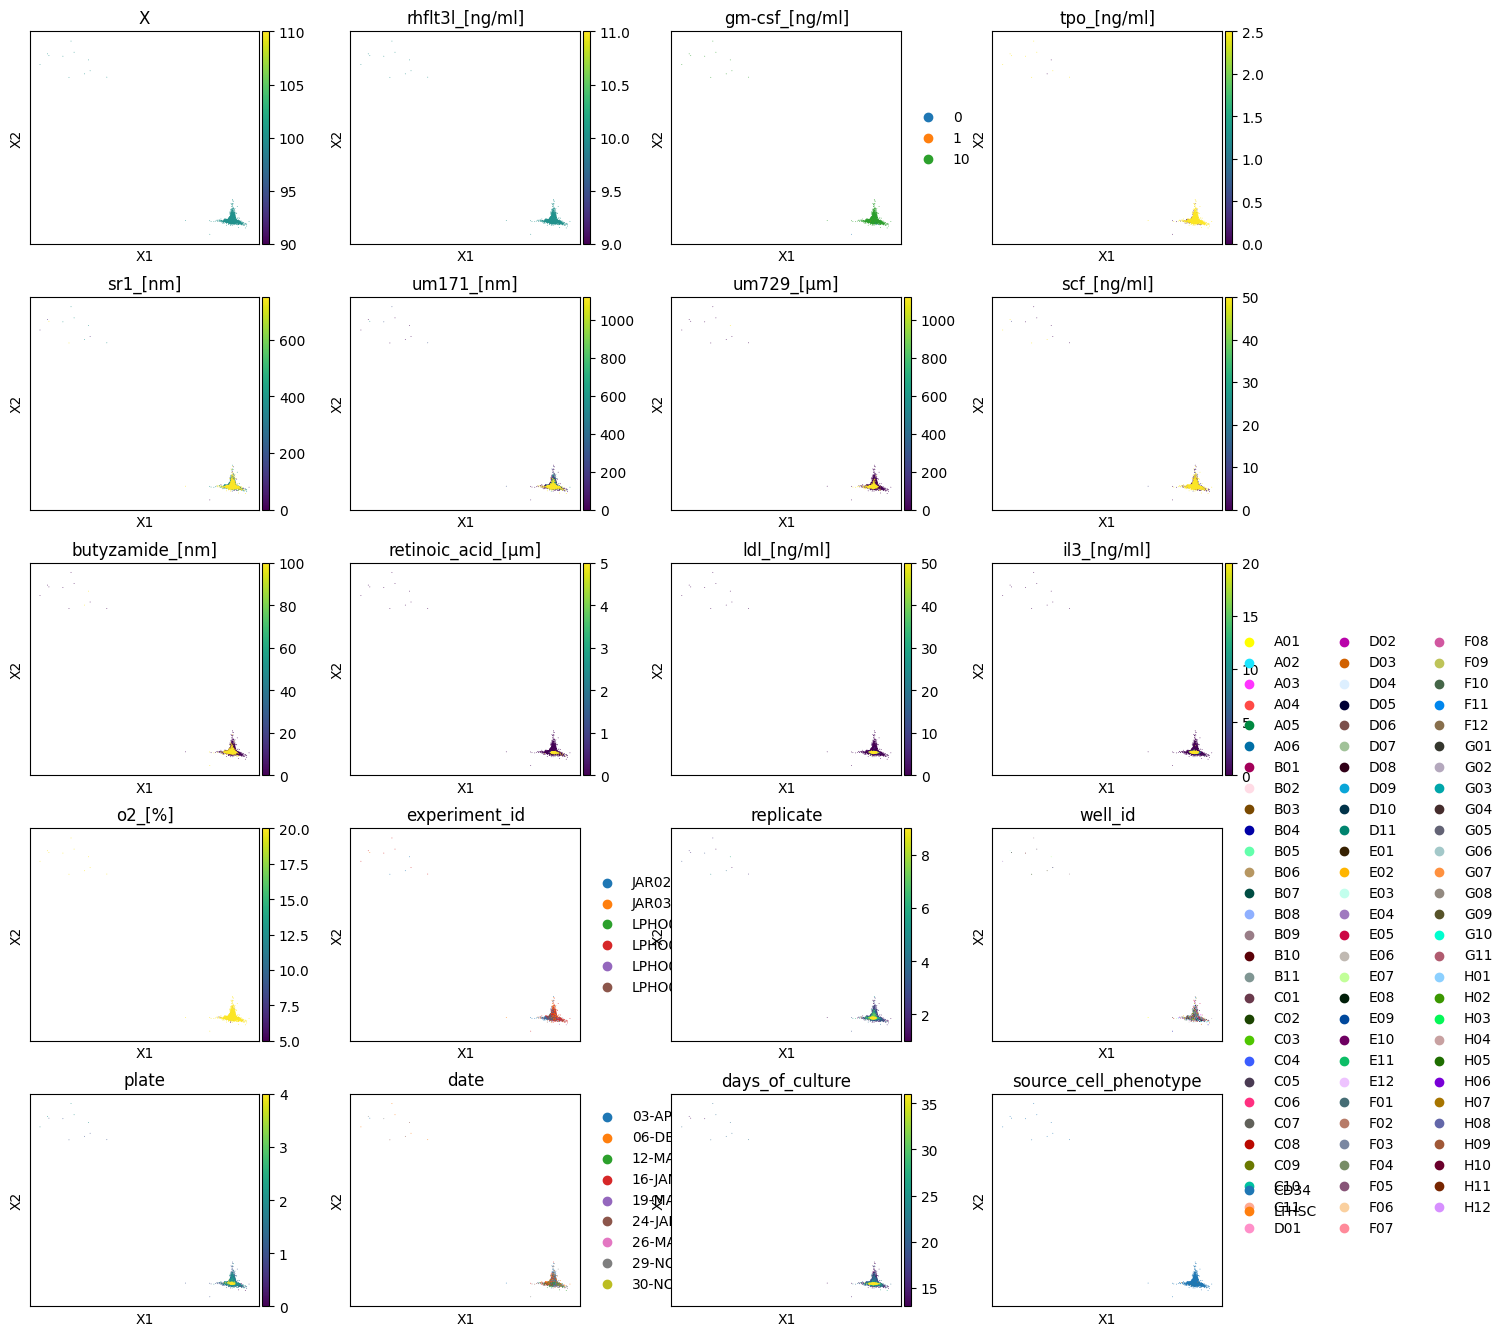

X_arcsinh_cof0.1


In [ ]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]', "experiment_id", "replicate", "well_id", 
    "plate", "date", "days_of_culture", "source_cell_phenotype"]

# iterating over the representations
for data_id, data in adata_umap.obsm.items():
    # handling keys
    pca_key = f"{data_id}_pca"
    neighbors_key = f"{data_id}_neighbors"
    umap_key = f"{data_id}_umap"
    print(data_id)
    sc.pl.embedding(adata_umap, color=EXPERIMENTAL_COLUMNS, basis=data_id,)


## Part 3: Analysing the experimental covariates in `adata.obs`.

### Plotting Histogram of # Samples per Experiment

In [ ]:
num_samples_per_experiment = adata.obs.groupby(by="experiment_number").size().values.reshape(-1, 1)
plt.figure()
sns.histplot(num_samples_per_experiment)
plt.grid(True)
plt.title("# Samples per Experiment")


### Barplot of # Samples per Days of culture.

In [ ]:
num_samples_per_days_of_culture = adata.obs.groupby(by="days_of_culture").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="days_of_culture").groups.keys()), y=num_samples_per_days_of_culture)
plt.title("# Samples per days of culture.")
plt.xlabel("# Days of Culture")
plt.ylabel("# Samples")
plt.grid(True)
plt.show()



### Barplot of # Samples per replicate.


In [ ]:
num_samples_per_replicate = adata.obs.groupby(by="replicate").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="replicate").groups.keys()), y=num_samples_per_replicate)
plt.title("# Samples per Replicates.")
plt.xlabel("Replicate")
plt.ylabel("# Samples")
plt.grid(True)
plt.show()



### Barplot of # Samples per Source Phenotype.

In [ ]:
num_samples_per_source_pheno = adata.obs.groupby(by="source_cell_phenotype").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="source_cell_phenotype").groups.keys()), y=num_samples_per_source_pheno)
plt.title("# Samples per Source Phenotype.")
plt.xlabel("Source Phenotype")
plt.ylabel("# Samples")
plt.grid(True)
plt.show()



### Barplot of # Samples per Hydrogel Type.


In [ ]:
num_samples_per_hydrogel_type = adata.obs.groupby(by="hydrogel_type").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="hydrogel_type").groups.keys()), y=num_samples_per_hydrogel_type)
plt.title("# Samples per Hydrogel Type.")
plt.xlabel("Hydrogel Type")
plt.ylabel("# Samples")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()



### Histplot of # Samples per Batch.

In [ ]:
num_samples_per_batch = adata.obs.groupby(by="batch").size().values
plt.figure()
sns.histplot(num_samples_per_batch)
plt.title("# Samples per Batch.")
plt.ylabel("# Batches")
plt.xlabel("# Samples per batch")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()


### Plotting Histogram of # Samples per Well

In [ ]:
num_samples_per_well = adata.obs.groupby(by="well_id").size().values
plt.figure(figsize=(5, 5))
sns.barplot(x=list(adata.obs.groupby(by="well_id").groups.keys()), y=num_samples_per_well)
plt.title("# Samples per well.")
plt.ylabel("# Samples")
plt.xticks(rotation=90, fontsize=8)
plt.grid(True)
plt.show()


### Barplot of # Samples per Plate


In [ ]:
num_samples_per_plate = adata.obs.groupby(by="plate").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="plate").groups.keys()), y=num_samples_per_plate)
plt.title("# Samples per Plate.")
plt.ylabel("# Samples")
plt.grid(True)
plt.show()


### Barplot of # Sampler per replicate.

In [ ]:
num_samples_per_replicate = adata.obs.groupby(by="replicate").size().values
plt.figure()
sns.barplot(x=list(adata.obs.groupby(by="replicate").groups.keys()), y=num_samples_per_replicate)
plt.title("# Samples per Replicate.")
plt.ylabel("# Samples")
plt.grid(True)
plt.show()


### Heatmap of number of samples per well.

In [ ]:
letter2int = {chr(i): i - ord('A') for i in range(ord('A'), ord('Z') + 1)}
int2letter = {v:k for k, v in letter2int.items()}
well2idx = {well:(letter2int[well[0]], int(well[1:]) -1) for well in adata.obs.well_id}
num_rows = max([well[0] for well in well2idx.values()]) + 1
num_cols = max([well[1] for well in well2idx.values()]) + 1
well_data = np.zeros((num_rows, num_cols), dtype=int)
for well, idxs in adata.obs.groupby(by="well_id").groups.items():
    n_obs = len(idxs)
    idx = well2idx[well]
    well_data[idx] = n_obs
plt.figure(figsize=(10, 6))
sns.heatmap(well_data, fmt='d', yticklabels=[int2letter[idx] for idx in range(num_rows)], xticklabels=np.arange(num_cols), annot=True)
plt.title(f"# samples per well.")


## Part 4: Analyzing the Forward and Side Scatter Data.

### Storing Scatter Data inside a `pandas.DataFrame`.

In [ ]:
SCATTER_COLUMNS = ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width']
scatter_df = adata_original.obs[SCATTER_COLUMNS]
scatter_df


### Correlation between scatter values

In [ ]:
corr_antibodies = np.corrcoef(scatter_df.values.T)
plt.figure()
sns.heatmap(corr_antibodies, fmt='d', xticklabels=SCATTER_COLUMNS, yticklabels=SCATTER_COLUMNS)
plt.title(f"Covariance between scatter values.")


### Computing summary statistics per each scatter value.

In [ ]:
min_scatter = scatter_df.min(0).values
max_scatter = scatter_df.max(0).values
mean_scatter = scatter_df.mean(0).values
median_scatter = scatter_df.median(0).values
std_scatter = scatter_df.std(0).values


### Min-Max 

In [ ]:
plt.figure()
plt.scatter(min_scatter, max_scatter)
plt.title("Min-max plot per scatter value.")
plt.xlabel("Min")
plt.ylabel("Max")
plt.grid(True)
plt.show()


### Mean-Std

In [ ]:
plt.figure()
plt.scatter(mean_scatter, std_scatter)
plt.title("Mean-Std plot per scatter value.")
plt.xlabel("Mean")
plt.ylabel("Std")
plt.grid(True)
plt.show()


### Histogram of each scatter value.

In [ ]:
for col in SCATTER_COLUMNS:    
    plt.figure()
    sns.histplot(adata.obs[[col]].values) 
    plt.title(col)
    plt.grid(True)
    plt.show()


## Part 5: Inspecting within and between batch variability.

### Computing summary statistic for each batch.

In [ ]:
stats_per_batch = {}
for batch, idxs in adata.obs.groupby(by="batch").groups.items():
    adata_batch = adata[idxs]
    batch_summary_stats_dict = {}
    batch_summary_stats_dict["X"] = compute_summary_stats(adata_batch.X)
    for key, val in adata_batch.obsm.items():
        batch_summary_stats_dict[key] = compute_summary_stats(val)
    stats_per_batch[int(batch)] = batch_summary_stats_dict


### Grouping the statistics over each transformation.

In [ ]:
all_transformation_stats = {}
channel_transformation_stats = {}
obs_transformation_stats = {}
for batch_id, batch_stats_dict in stats_per_batch.items():
    for batch_data_id, batch_stats in batch_stats_dict.items():
        all_stats = batch_stats[None]        
        if batch_data_id not in all_transformation_stats.keys():
            all_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in all_stats.items():
            if stat_id not in all_transformation_stats[batch_data_id].keys():
                all_transformation_stats[batch_data_id][stat_id] = []
            all_transformation_stats[batch_data_id][stat_id].append(all_stats[stat_id])
    
        channel_stats = batch_stats[0]        
        if batch_data_id not in channel_transformation_stats.keys():
            channel_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in channel_stats.items():
            if stat_id not in channel_transformation_stats[batch_data_id].keys():
                channel_transformation_stats[batch_data_id][stat_id] = []
            channel_transformation_stats[batch_data_id][stat_id].append(channel_stats[stat_id])
        
        obs_stats = batch_stats[1]
        if batch_data_id not in obs_transformation_stats.keys():
            obs_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in obs_stats.items():
            if stat_id not in obs_transformation_stats[batch_data_id].keys():
                obs_transformation_stats[batch_data_id][stat_id] = []
            obs_transformation_stats[batch_data_id][stat_id].append(obs_stats[stat_id])


### Plotting distribution of summary statistics across batches for each transformation.

In [ ]:
for data_id, data_stats in all_transformation_stats.items():
    fig, axes = plt.subplots(1, len(data_stats), figsize=(10, 5))
    fig.suptitle(data_id)
    for idx, (stat_id, stat_val) in enumerate(data_stats.items()):
        stat_val = np.stack(stat_val)
        axes[idx].set_title(stat_id)
        sns.histplot(stat_val, ax=axes[idx])


### Variance decomposition across batches.

In [ ]:
weights = np.array([len(adata.obs.groupby("batch").groups[str(b)]) for b in sorted(stats_per_batch.keys())])
weights = weights / np.sum(weights)  # Normalize
var_dec_per_tras = {}
for trans_id, trans_stats in all_transformation_stats.items():
    print(f"Performing variance decomposition for data {trans_id}")
    mean = np.stack(trans_stats["mean"])
    var = np.stack(trans_stats["std"])**2    
    # weighted mean 
    weighted_mean = np.average(mean, axis=0, weights=weights)
    # variance of batch means (weighted)
    var_mean = np.average((mean - weighted_mean) ** 2, axis=0, weights=weights)
    # average batch variance (weighted)
    mean_var = np.average(var, axis=0, weights=weights)
    tot_var = var_mean + mean_var
    # assert tot_var == summary_stats_dict[trans_id][None]["std"]**2, f"{tot_var=} {summary_stats_dict[trans_id][None]['std']**2=}"
    var_dec_per_tras[trans_id] = {
        "variance_of_means": var_mean,
        "mean_of_variances": mean_var,
        "total_variance": tot_var,
        "explained_variance": var_mean/tot_var,
        "original_variance": summary_stats_dict[trans_id][None]['std']**2,
    }
    print(f"\t explained variance: {var_mean/tot_var}")


## Part 6: Inspecting within and between experiments variability.


### Computing summary statistic for each experiment.


In [ ]:
stats_per_experiment = {}
for batch, idxs in adata.obs.groupby(by="experiment_number").groups.items():
    adata_experiment = adata[idxs]
    experiment_summary_stats_dict = {}
    experiment_summary_stats_dict["X"] = compute_summary_stats(adata_experiment.X)
    for key, val in adata_experiment.obsm.items():
        batch_summary_stats_dict[key] = compute_summary_stats(val)
    stats_per_experiment[int(batch)] = batch_summary_stats_dict


### Grouping the statistics over each transformation.


In [ ]:
all_transformation_stats = {}
channel_transformation_stats = {}
obs_transformation_stats = {}
for batch_id, batch_stats_dict in stats_per_experiment.items():
    for batch_data_id, batch_stats in batch_stats_dict.items():
        all_stats = batch_stats[None]        
        if batch_data_id not in all_transformation_stats.keys():
            all_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in all_stats.items():
            if stat_id not in all_transformation_stats[batch_data_id].keys():
                all_transformation_stats[batch_data_id][stat_id] = []
            all_transformation_stats[batch_data_id][stat_id].append(all_stats[stat_id])
    
        channel_stats = batch_stats[0]        
        if batch_data_id not in channel_transformation_stats.keys():
            channel_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in channel_stats.items():
            if stat_id not in channel_transformation_stats[batch_data_id].keys():
                channel_transformation_stats[batch_data_id][stat_id] = []
            channel_transformation_stats[batch_data_id][stat_id].append(channel_stats[stat_id])
        
        obs_stats = batch_stats[1]
        if batch_data_id not in obs_transformation_stats.keys():
            obs_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in obs_stats.items():
            if stat_id not in obs_transformation_stats[batch_data_id].keys():
                obs_transformation_stats[batch_data_id][stat_id] = []
            obs_transformation_stats[batch_data_id][stat_id].append(obs_stats[stat_id])


In [ ]:
for data_id, data_stats in all_transformation_stats.items():
    fig, axes = plt.subplots(1, len(data_stats), figsize=(10, 5))
    fig.suptitle(data_id)
    for idx, (stat_id, stat_val) in enumerate(data_stats.items()):
        stat_val = np.stack(stat_val)
        axes[idx].set_title(stat_id)
        sns.histplot(stat_val, ax=axes[idx])


### Variance decomposition across experiments.

In [ ]:
weights = np.array([len(adata.obs.groupby("experiment_number").groups[b]) for b in sorted(stats_per_experiment.keys())])
weights = weights / np.sum(weights)  # Normalize
var_dec_per_tras = {}
for trans_id, trans_stats in all_transformation_stats.items():
    print(f"Performing variance decomposition for data {trans_id}")
    mean = np.stack(trans_stats["mean"])
    var = np.stack(trans_stats["std"])**2    
    # weighted mean 
    weighted_mean = np.average(mean, axis=0, weights=weights)
    # variance of batch means (weighted)
    var_mean = np.average((mean - weighted_mean) ** 2, axis=0, weights=weights)
    # average batch variance (weighted)
    mean_var = np.average(var, axis=0, weights=weights)
    tot_var = var_mean + mean_var
    # assert tot_var == summary_stats_dict[trans_id][None]["std"]**2, f"{tot_var=} {summary_stats_dict[trans_id][None]['std']**2=}"
    var_dec_per_tras[trans_id] = {
        "variance_of_means": var_mean,
        "mean_of_variances": mean_var,
        "total_variance": tot_var,
        "explained_variance": var_mean/tot_var,
        "original_variance": summary_stats_dict[trans_id][None]['std']**2,
    }
    print(f"\t explained variance: {var_mean/tot_var}")


## Part 7: Inspecting within and between replicates variability.


In [ ]:
stats_per_experiment = {}
for batch, idxs in adata.obs.groupby(by="replicate").groups.items():
    adata_experiment = adata[idxs]
    experiment_summary_stats_dict = {}
    experiment_summary_stats_dict["X"] = compute_summary_stats(adata_experiment.X)
    for key, val in adata_experiment.obsm.items():
        batch_summary_stats_dict[key] = compute_summary_stats(val)
    stats_per_experiment[int(batch)] = batch_summary_stats_dict


In [ ]:
all_transformation_stats = {}
channel_transformation_stats = {}
obs_transformation_stats = {}
for batch_id, batch_stats_dict in stats_per_experiment.items():
    for batch_data_id, batch_stats in batch_stats_dict.items():
        all_stats = batch_stats[None]        
        if batch_data_id not in all_transformation_stats.keys():
            all_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in all_stats.items():
            if stat_id not in all_transformation_stats[batch_data_id].keys():
                all_transformation_stats[batch_data_id][stat_id] = []
            all_transformation_stats[batch_data_id][stat_id].append(all_stats[stat_id])
    
        channel_stats = batch_stats[0]        
        if batch_data_id not in channel_transformation_stats.keys():
            channel_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in channel_stats.items():
            if stat_id not in channel_transformation_stats[batch_data_id].keys():
                channel_transformation_stats[batch_data_id][stat_id] = []
            channel_transformation_stats[batch_data_id][stat_id].append(channel_stats[stat_id])
        
        obs_stats = batch_stats[1]
        if batch_data_id not in obs_transformation_stats.keys():
            obs_transformation_stats[batch_data_id] = {}
        for stat_id, stat_value in obs_stats.items():
            if stat_id not in obs_transformation_stats[batch_data_id].keys():
                obs_transformation_stats[batch_data_id][stat_id] = []
            obs_transformation_stats[batch_data_id][stat_id].append(obs_stats[stat_id])


In [ ]:
for data_id, data_stats in all_transformation_stats.items():
    fig, axes = plt.subplots(1, len(data_stats), figsize=(10, 5))
    fig.suptitle(data_id)
    for idx, (stat_id, stat_val) in enumerate(data_stats.items()):
        stat_val = np.stack(stat_val)
        axes[idx].set_title(stat_id)
        sns.histplot(stat_val, ax=axes[idx])


In [ ]:
weights = np.array([len(adata.obs.groupby("replicate").groups[b]) for b in sorted(stats_per_experiment.keys())])
weights = weights / np.sum(weights)  # Normalize
var_dec_per_tras = {}
for trans_id, trans_stats in all_transformation_stats.items():
    print(f"Performing variance decomposition for data {trans_id}")
    mean = np.stack(trans_stats["mean"])
    var = np.stack(trans_stats["std"])**2    
    # weighted mean 
    weighted_mean = np.average(mean, axis=0, weights=weights)
    # variance of batch means (weighted)
    var_mean = np.average((mean - weighted_mean) ** 2, axis=0, weights=weights)
    # average batch variance (weighted)
    mean_var = np.average(var, axis=0, weights=weights)
    tot_var = var_mean + mean_var
    # assert tot_var == summary_stats_dict[trans_id][None]["std"]**2, f"{tot_var=} {summary_stats_dict[trans_id][None]['std']**2=}"
    var_dec_per_tras[trans_id] = {
        "variance_of_means": var_mean,
        "mean_of_variances": mean_var,
        "total_variance": tot_var,
        "explained_variance": var_mean/tot_var,
        "original_variance": summary_stats_dict[trans_id][None]['std']**2,
    }
    print(f"\t explained variance: {var_mean/tot_var}")


## Part 8: Inspecting the experimental covariates and their values.

### Subsetting `adata.obs` to the columns of interest.

In [ ]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng/ml]', 'gm-csf_[ng/ml]', 'tpo_[ng/ml]', 'sr1_[nm]',
    'um171_[nm]', 'um729_[µm]', 'scf_[ng/ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]',
    'ldl_[ng/ml]', 'il3_[ng/ml]', 'o2_[%]',
]
exp_obs_df = adata.obs[EXPERIMENTAL_COLUMNS]
exp_obs_df


### Checking types.

In [ ]:
exp_obs_df.dtypes


### Checking number of unique values for integer of categorical variables.

In [ ]:
for col in exp_obs_df.columns:
    print(col, "# unique values", exp_obs_df[col].nunique())


In [ ]:
for col in exp_obs_df.columns:
    plt.figure(figsize=(3, 3))
    plt.title(col)
    sns.barplot(exp_obs_df[col].values)
    

### Computing summary statistics for continuous values.

In [ ]:
summary_stats_exp_col_dict = {}
for col in exp_obs_df.columns:
    if exp_obs_df[col].dtype == np.float64:
        summary_stats_exp_col_dict[col] = compute_summary_stats(
            exp_obs_df[col].values.reshape(-1, 1)
        )
for col, stats in summary_stats_exp_col_dict.items():
    print(col)
    for k, v in stats[None].items():
        print("\t", k, v)


### Plotting histograms for continuous values.

In [ ]:
for col in exp_obs_df.columns:
    if exp_obs_df[col].dtype == np.float64:
        plt.figure(figsize=(3, 3))
        plt.title(col)
        sns.histplot(exp_obs_df[col].values)


## Part 9: Checking what axis the conditions vary over.

In [ ]:
for key, value in adata.obs.groupby(by="experiment_number").groups.items():
    ...


## Part _: Grouping the experiments according to temporal resolution.

### Creating a mapping containing each consecutive experiment.

In [ ]:
experiment_numbers = np.sort(adata_original.obs["experiment_number"].unique())
result = {}
base_values = experiment_numbers[experiment_numbers < 1000]

for base in np.unique(base_values):
    matches = experiment_numbers[experiment_numbers % 1000 == base]
    result[str(base)] = matches.tolist()
